In [1]:
import SimpleITK as sitk
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
def showImage(image, dims=None):
    image = sitk.GetArrayViewFromImage(image)
    if dims == None:
        dims = [x // 2 for x in np.shape(image)]
    mip = np.max(image, axis=1)
    plt.figure(figsize=(15,10))
    plt.subplot(1,4,1)
    plt.imshow(image[dims[0], :, :], cmap='gray')
    plt.title('axial')
    plt.subplot(1,4,2)
    plt.imshow(image[:, dims[1], :], cmap='gray')
    plt.title('coronal')
    plt.subplot(1,4,3)
    plt.imshow(image[:,:,dims[2]], cmap='gray')
    plt.title('sagittal')
    plt.subplot(1,4,4)
    plt.imshow(mip, cmap='gray')
    plt.title('MIP')

In [3]:
seg_dir = r'/run/user/2335777/gvfs/smb-share:server=lc-rs-store25.hpc.uiowa.edu,share=teamwork/SierenLab/AP14120_Alpha/PCCT_and_Force_Pig_Airways_for_JCS'
fain = sitk.ReadImage(os.path.join(seg_dir, 'Fain.nii.gz'), sitk.sitkFloat64)
sn = sitk.ReadImage(os.path.join(seg_dir, 'Sn.nii.gz'), sitk.sitkFloat64)

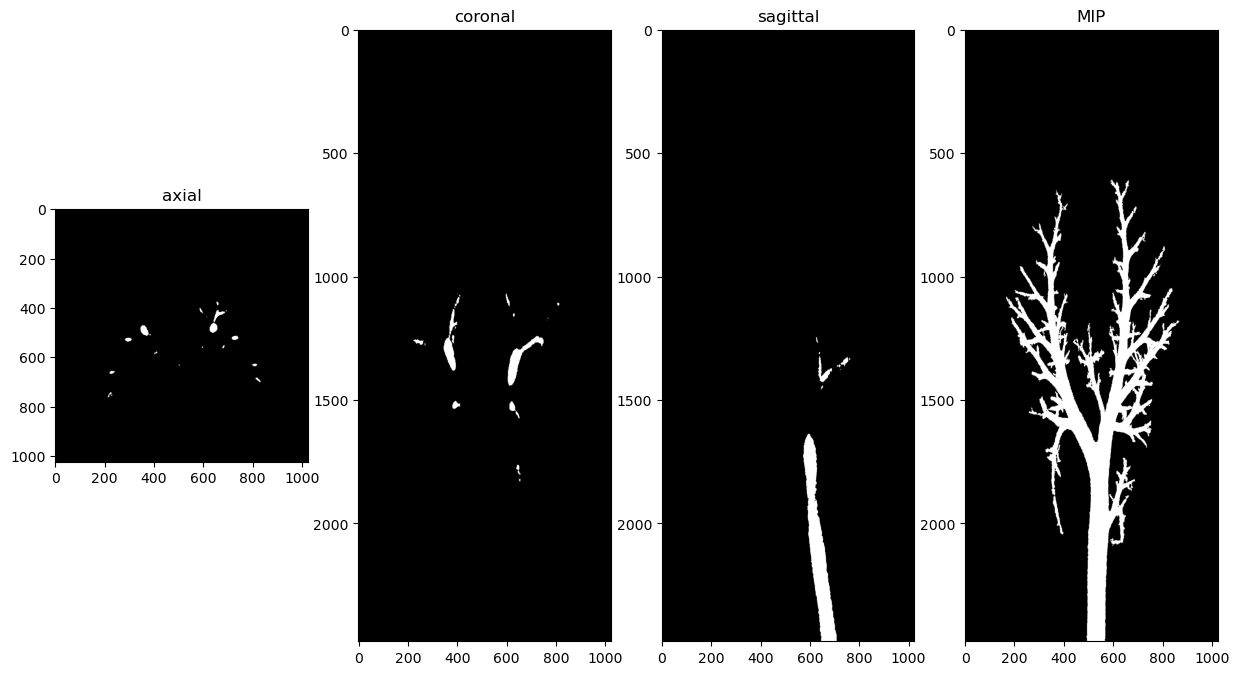

In [4]:
showImage(fain)

### Registration

In [6]:
# directly from https://simpleitk.readthedocs.io/en/master/link_ImageRegistrationMethod1_docs.html

def command_iteration(method):
    """ Callback invoked when the optimization process is performing an iteration. """
    print(
        f"{method.GetOptimizerIteration():3} "
        + f"= {method.GetMetricValue():10.5f} "
        + f": {method.GetOptimizerPosition()}"
    )
    
fixed = sn
moving = fain
    
R = sitk.ImageRegistrationMethod()
R.SetMetricAsMeanSquares()
R.SetMetricSamplingStrategy(R.RANDOM)
R.SetMetricSamplingPercentage(0.1)

R.SetOptimizerAsRegularStepGradientDescent(
    learningRate=1.0,
    minStep=1e-6,
    numberOfIterations=300,
    gradientMagnitudeTolerance=1e-8,
)
R.SetOptimizerScalesFromPhysicalShift() # weight rotation and translation equally

initial_transform = sitk.CenteredTransformInitializer(
    fixed,
    moving,
    sitk.Euler3DTransform(),
    sitk.CenteredTransformInitializerFilter.GEOMETRY,
)

R.SetInitialTransform(initial_transform, inPlace=False)
R.SetInterpolator(sitk.sitkNearestNeighbor)

R.SetShrinkFactorsPerLevel([4, 2, 1])
R.SetSmoothingSigmasPerLevel([2, 1, 0])
R.SmoothingSigmasAreSpecifiedInPhysicalUnitsOn()

R.AddCommand(sitk.sitkIterationEvent, lambda: command_iteration(R))
outTx = R.Execute(fixed, moving)

print("-------")
print(outTx)
print(f"Optimizer stop condition: {R.GetOptimizerStopConditionDescription()}")
print(f" Iteration: {R.GetOptimizerIteration()}")
print(f" Metric value: {R.GetMetricValue()}")

resampler = sitk.ResampleImageFilter()
resampler.SetReferenceImage(fixed)
resampler.SetInterpolator(sitk.sitkNearestNeighbor)
resampler.SetDefaultPixelValue(0)
resampler.SetTransform(outTx)
out = resampler.Execute(moving)

  0 =    0.00096 : (0.0016738724737397446, 0.00033041243828176763, -0.0002292876160879511, 0.08518711529894381, -0.8536767805942745, 35.763779190557514)
  1 =    0.00081 : (0.00293085942483413, 0.0007183655505301034, -0.00040147641655067975, 0.17026278076784196, -1.5977078243675926, 36.42648438660913)
  2 =    0.00071 : (0.003292637088715997, 0.0011333920437850147, -0.00042564265786933643, 0.21055937703823285, -2.0274946728362866, 37.328514954549206)
  3 =    0.00064 : (0.002515483764439586, 0.0014242204955851748, -0.0002470955428226403, 0.15303805425451333, -1.9148525950029909, 38.320483875080015)
  4 =    0.00057 : (0.0018241429725731535, 0.0016431420965535863, -5.0708254802544274e-05, 0.08067737262101722, -1.7257436506048753, 39.29976992851662)
  5 =    0.00050 : (0.0013549480805085544, 0.0018331007284975599, 0.00012293446361744432, 0.030524944349207044, -1.5302405142086504, 40.27918963998753)
  6 =    0.00043 : (0.001056744055703428, 0.0019621229392690885, 0.00027976813684777525, -

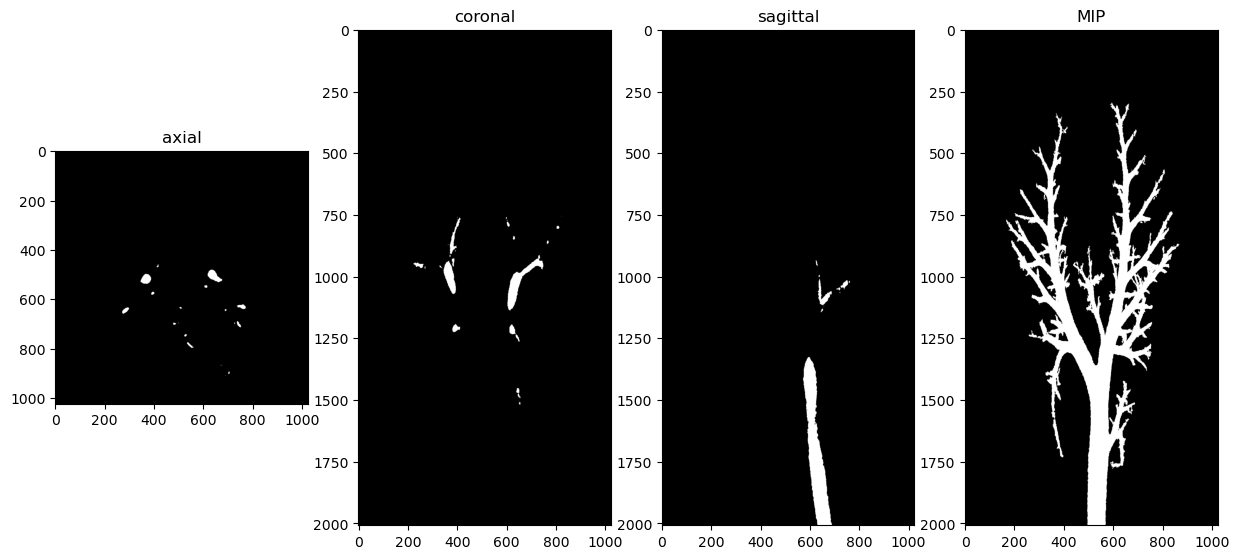

In [7]:
showImage(out)